In [1]:
import pandas as pd
df=pd.read_csv("retail_sales_dataset.csv")

In [6]:
df.head(50)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24/11/2023,CUST001,Male,34,Beauty,3,50,150
1,2,27/02/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13/01/2023,CUST003,Male,50,Electronics,1,30,30
3,4,21/05/2023,CUST004,Male,37,Clothing,1,500,500
4,5,06/05/2023,CUST005,Male,30,Beauty,2,50,100
5,6,25/04/2023,CUST006,Female,45,Beauty,1,30,30
6,7,13/03/2023,CUST007,Male,46,Clothing,2,25,50
7,8,22/02/2023,CUST008,Male,30,Electronics,4,25,100
8,9,13/12/2023,CUST009,Male,63,Electronics,2,300,600
9,10,07/10/2023,CUST010,Female,52,Clothing,4,50,200


In [2]:
print("Shape (Rows, Columns):", df.shape)

Shape (Rows, Columns): (1000, 9)


In [3]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [4]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [6]:
#View a comprehensive summary (dtypes + non-null counts)
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
QUESTION 2,
Descriptive statistics: mean, median, mode, standard deviation for all numerical columns


In [12]:
# Select numerical columns
numerical_columns = df.select_dtypes(include='number').columns

# Calculate descriptive statistics
descriptive_stats = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

# Display the results

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [13]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check the result
df[['Date', 'Total Amount']].head()

,Date,Total Amount
0,2023-11-24,150
1,2023-02-27,1000
2,2023-01-13,30
3,2023-05-21,500
4,2023-05-06,100


### Observation

The descriptive statistics provide an overview of the numerical variables in the dataset. 
The mean and median show the central values, while the mode identifies the most frequently occurring value.
The standard deviation shows the level of variation in each numerical variable.

In [ ]:
QUESTION 3

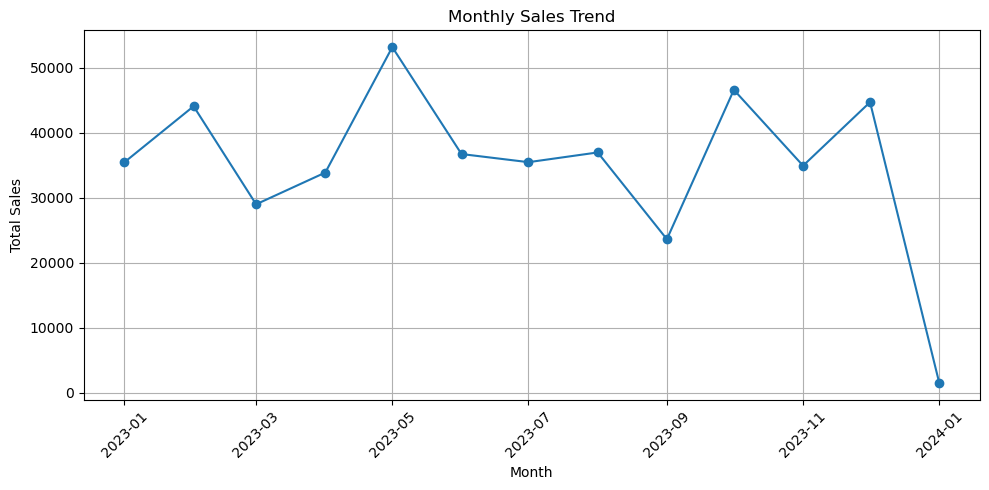

In [18]:

import matplotlib.pyplot as plt

# Create monthly sales
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

# Convert period to timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot monthly sales trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Observation

The monthly sales trend shows how revenue changes over time.Peaks in the line represent months with higher sales, while drops represent periods of lower sales.This helps identify strong and weak sales periods.

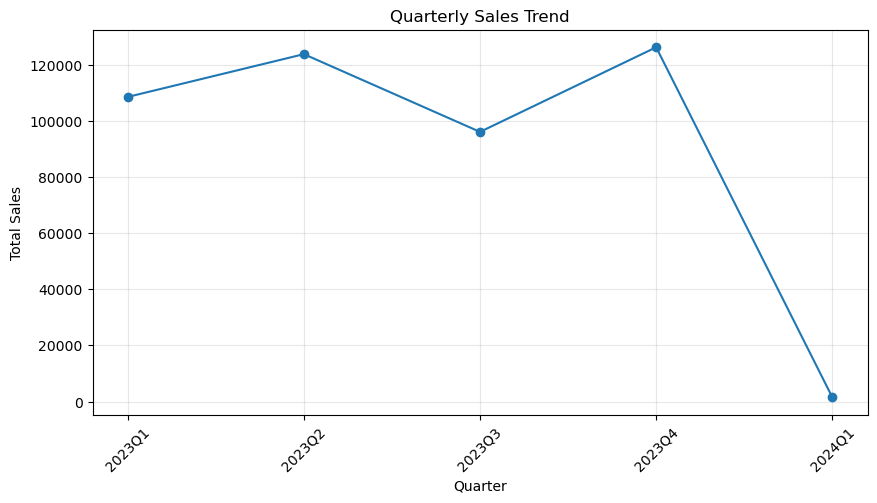

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

### Observation
The quarterly sales trend provides a broader view of the business performance over time.Higher points indicate stronger quarterly sales, while lower points indicate weaker performance. This can help the business identify periods of growth or decline.

In [ ]:
QUESTION 4,
CREATE MEANINGFUL AGE GROUPS

In [20]:
# Create age groups
bins = [0, 17, 25, 39, 59, 100]
labels = ['0-17', '18-25', '26-39', '40-59', '60+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Check the age groups
df['Age Group'].value_counts().sort_index()

Age Group
0-17       0
18-25    169
26-39    273
40-59    443
60+      115
Name: count, dtype: int64

In [ ]:
QUESTION 4  Customer demographics analysis: distribution of customer age groups, gender breakdown
Plot AGE GROUP DISTRIBUTION 

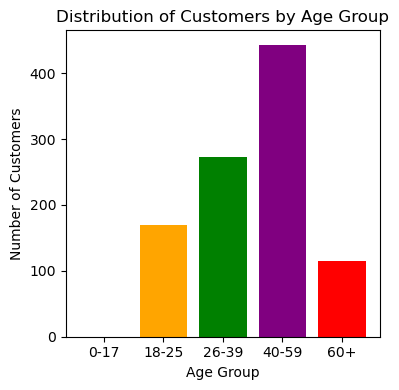

In [27]:
import matplotlib.pyplot as plt

age_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(4, 4))

plt.bar(
    age_counts.index,
    age_counts.values,
    color=['skyblue', 'orange', 'green', 'purple', 'red']
)

plt.title('Distribution of Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation
The bar chart shows the distribution of customers across different age groups.The largest number of customers belongs to the age group with the highest bar,while the lowest bar represents the age group with the fewest customers. 
This indicates which age group forms the main customer segment.

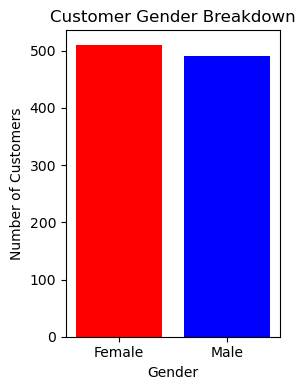

In [13]:
import matplotlib.pyplot as plt

# Count each gender
gender_counts = df['Gender'].value_counts()

# Create bar chart
plt.figure(figsize=(3, 4))

plt.bar(
    gender_counts.index,
    gender_counts.values,
    color=['red', 'blue']
)

plt.title('Customer Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation

The gender breakdown shows the number of male and female customers in the dataset.The gender with the higher bar represents the larger proportion of customers. This information can help the business understand the gender composition of its customer base.

In [ ]:

QUESTION 5
Top 10 best-selling products/categories

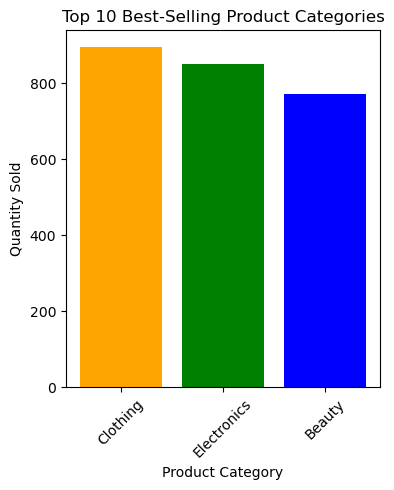

In [12]:
import matplotlib.pyplot as plt

# Calculate top 10 best-selling categories
top_products = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Assign colours to the 3 categories
colors = {
    'Beauty': 'blue',
    'Clothing': 'orange',
    'Electronics': 'green'
}

# Create the bar chart
plt.figure(figsize=(4, 5))

plt.bar(
    top_products.index,
    top_products.values,
    color=[colors[category] for category in top_products.index]
)

plt.title('Top 10 Best-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The bar chart shows the best-selling product categories based on the quantity sold.The category with the highest bar has the largest number of units sold, while the category with the lowest bar has the fewest units sold.

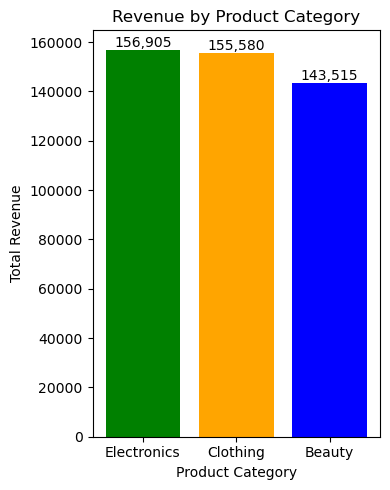

In [20]:
import matplotlib.pyplot as plt

# Calculate total revenue for each product category
category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

# Assign a different colour to each category
colors = {
    'Beauty': 'blue',
    'Clothing': 'orange',
    'Electronics': 'green'
}

# Create the bar chart
plt.figure(figsize=(4, 5))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values,
    color=[colors[category] for category in category_revenue.index]
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

# Add revenue values on top of each bar
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Observation

The chart shows the total revenue generated by each product category. The category with the highest bar contributes the most revenue to the business, while the category with the lowest bar contributes the least. This helps identify which product categories are the strongest revenue generators.

In [ ]:
QUESTION 6  Heatmap: correlation matrix between numerical variables


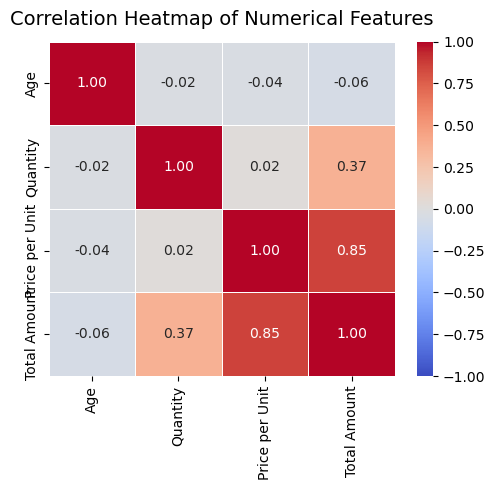

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features (excluding ID columns)
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

# Compute Pearson correlation matrix
corr_matrix = df[num_cols].corr()

# Configure and display heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [ ]:
QUESTION 7 At least one additional visualisation of your choice that reveals a non-obvious insight


<Figure size 1000x600 with 0 Axes>

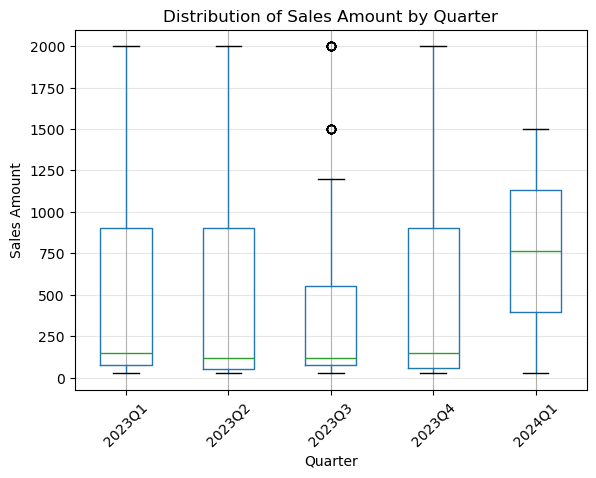

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Make sure Total Amount is numeric
df['Total Amount'] = pd.to_numeric(df['Total Amount'], errors='coerce')

# Create quarter column
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)

# Create boxplot
plt.figure(figsize=(10, 6))

df.boxplot(
    column='Total Amount',
    by='Quarter'
)

plt.title('Distribution of Sales Amount by Quarter')
plt.suptitle('')
plt.xlabel('Quarter')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

Conclusion and Business Recommendations

You can add the following as the Conclusion section of your Jupyter Notebook:

Conclusion

The analysis provided insights into the company's sales performance, customer purchasing behaviour, product performance, and sales trends over time. The visualisations helped identify the best-selling products, differences in revenue across product categories, and changes in sales across months and quarters.

Based on these findings, the following actionable recommendations are proposed:

1. Focus on the best-selling products

The business should maintain sufficient stock of the top-performing products because they contribute significantly to overall sales. Inventory levels should be monitored regularly to reduce the risk of stockouts, especially during periods of high demand.

Action: Prioritise inventory and marketing budgets for the top 10 best-selling products.

2. Improve the performance of weaker product categories

Products or categories generating lower revenue should be reviewed to understand why they are underperforming. The business can use discounts, bundles, promotions, or targeted marketing to increase their sales.

Action: Run targeted promotions or product bundles for low-performing categories and compare their sales performance before and after the campaigns.

3. Plan inventory and marketing around quarterly trends

The quarterly sales analysis can help the business identify periods of high and low sales activity. Marketing campaigns, promotions, and inventory purchases should be increased ahead of high-performing quarters and adjusted during weaker periods.

Action: Prepare inventory and promotional campaigns several weeks before historically strong quarters.

4. Investigate unusually large transactions

The sales distribution analysis showed that some transactions may be significantly higher than typical purchases. These high-value transactions could represent valuable customers or bulk purchases.

Action: Identify customers responsible for high-value transactions and introduce loyalty programmes, personalised offers, or bulk-purchase incentives to encourage repeat purchases.

5. Monitor sales performance regularly

The business should continue tracking key sales metrics rather than relying on occasional analysis.

Action: Create a monthly sales dashboard showing total revenue, best-selling products, product-category performance, average transaction value, and quarterly growth so management can make faster, data-driven decisions.

Overall Recommendation

The business should focus its resources on high-performing products, improve weaker product categories through targeted promotions, and use quarterly sales patterns to plan inventory and marketing activities. Regular monitoring of sales KPIs will help the business identify changes in customer behaviour and respond quickly to new opportunities or declining performance.